# Práctica 12 · Qué dicen los datos sobre el servicio actual

Antes de proponer un chatbot conviene saber dónde falla hoy el servicio. No por intuición: con
datos.

Esta práctica explora expedientes reales presentados ante el Indecopi por consumidores peruanos.
No son datos inventados para el curso ni un ejemplo de manual: son las denuncias, apelaciones y
quejas que llegaron al regulador durante dos años, con el sector, el tema y la empresa
denunciada.

Al terminar vas a poder responder tres preguntas con evidencia: dónde se concentran los
problemas de servicio, si esa concentración es estable, y qué parte de ella podría atender un
asistente automático. Esa última respuesta es la que sostiene el caso de negocio de todo lo demás
que verás esta semana.

También vas a ver algo que importa tanto como los hallazgos: qué **no** se puede concluir de estos
datos. Un análisis que no dice dónde están sus límites no sirve para decidir.

No hace falta Ollama ni ningún modelo. Corre en segundos.

In [1]:
%pip install --quiet pandas openpyxl matplotlib

print("Listo.")


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: /Users/fgrodriguez/ESAN_GlobalWeek2026/09_Notebooks_RAG/.venv/bin/python -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
Listo.


## 2. De dónde salen estos datos

El Indecopi, que es el organismo peruano de defensa del consumidor, publica sus expedientes en la
Plataforma Nacional de Datos Abiertos del Estado peruano.

Conviene detenerse en las tres cosas que hay que verificar de cualquier dato abierto antes de
usarlo, porque es una costumbre profesional y porque el curso trata sobre datos:

**Quién lo publica.** Indecopi, a través de `datosabiertos.gob.pe`. Es la fuente oficial, no un
intermediario.

**Con qué licencia.** Open Data Commons Attribution License. Permite usar, transformar y compartir
los datos, incluso comercialmente, con la única condición de atribuir la fuente. Por eso esta
práctica cita al Indecopi cada vez que muestra una cifra.

**Qué contiene exactamente.** Expedientes de protección al consumidor en materia financiera,
bancaria, de seguros, pensiones y salud humana, de 2015 y 2016.

Los archivos ya están descargados en la carpeta `datos_abiertos`, junto a este cuaderno. Si
quisieras bajarlos de nuevo, la celda siguiente muestra cómo, con un detalle práctico: el
servidor rechaza las peticiones que no parecen venir de un navegador, así que hay que
identificarse.

In [2]:
from pathlib import Path

CARPETA = Path("datos_abiertos")
archivos = sorted(CARPETA.glob("INDECOPI_*.xlsx"))

for a in archivos:
    print(f"  {a.name}  ({a.stat().st_size/1024:.0f} KB)")

# Así se descargarían de nuevo. La línea de "headers" es la que hace falta:
# sin ella el servidor devuelve una página de error en lugar del archivo.
#
# import requests
# url = ("https://www.datosabiertos.gob.pe/sites/default/files/"
#        "INDECOPI_CC1_ExpedientesPresentados_2016_0.xlsx")
# encabezados = {"User-Agent": "Mozilla/5.0"}
# respuesta = requests.get(url, headers=encabezados, timeout=90)
# Path("INDECOPI_expedientes_2016.xlsx").write_bytes(respuesta.content)

  INDECOPI_expedientes_2015.xlsx  (133 KB)
  INDECOPI_expedientes_2016.xlsx  (133 KB)


## 3. Abrir los datos y ver qué hay

Los archivos vienen en Excel. Para trabajar con ellos usamos pandas, que es la herramienta
estándar para manejar tablas en Python. Piensa en ella como una hoja de cálculo que se maneja con
instrucciones en lugar de con el ratón.

Un detalle del archivo: las dos primeras filas son título y espacio en blanco, no datos. Por eso
se saltan. Es lo primero que hay que revisar en cualquier archivo publicado: casi nunca viene
listo para usar.

In [3]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd

COLUMNAS = ["nro", "anio", "expediente", "tipo", "fecha",
            "sector", "subsector", "denunciado", "ruc"]

partes = []
for archivo in archivos:
    # skiprows=2 salta las dos primeras filas, que son título y espacio
    # en blanco, no datos. Casi ningún archivo publicado viene listo.
    tabla = pd.read_excel(archivo, skiprows=2)
    tabla.columns = COLUMNAS[:len(tabla.columns)]
    partes.append(tabla.dropna(subset=["sector"]))

# concat pega las tablas una debajo de otra. ignore_index=True renumera
# las filas desde cero, si no se repetirían los números de cada archivo.
datos = pd.concat(partes, ignore_index=True)

print(f"{len(datos):,} expedientes en total\n")
print(datos[["anio", "tipo", "sector", "subsector", "denunciado"]].head(4).to_string(index=False))

4,634 expedientes en total

 anio                      tipo                            sector          subsector                      denunciado
 2015                 APELACION SERVICIOS FINANCIEROS Y BANCARIOS TARJETA DE CREDITO        BANCO FALABELLA PERU S.A
 2015 SANCIONADOR POR EL ART. 5               SEGUROS Y PENSIONES    OTROS SERVICIOS RIMAC SEGUROS Y REASEGUROS S.A.
 2015                  DENUNCIA SERVICIOS FINANCIEROS Y BANCARIOS CREDITO DE CONSUMO   EDPYME ACCESO CREDITICIO S.A.
 2015                     QUEJA SERVICIOS FINANCIEROS Y BANCARIOS  CUENTA DE AHORROS                        ORPS N°2


In [4]:
# ¿Qué hay en cada columna? Esto es lo primero que se mira siempre.
print(f"{'columna':<14} {'valores distintos':>18}   ejemplo")
print("-" * 74)
for col in ["anio", "tipo", "sector", "subsector", "denunciado"]:
    print(f"{col:<14} {datos[col].nunique():>18}   {str(datos[col].iloc[0])[:34]}")

columna         valores distintos   ejemplo
--------------------------------------------------------------------------
anio                            2   2015
tipo                            5   APELACION
sector                          5   SERVICIOS FINANCIEROS Y BANCARIOS
subsector                      32   TARJETA DE CREDITO
denunciado                    967   BANCO FALABELLA PERU S.A


Fíjate en el contraste entre `sector`, que tiene poquísimos valores, y `denunciado`, que tiene
cientos. Esa diferencia es la que hace útil el análisis: los sectores agrupan y las empresas
detallan, y entre los dos está el nivel donde se toman las decisiones.

## 4. Qué tipo de expedientes son

Antes de contar cosas conviene entender qué se está contando. No todos los expedientes son
iguales, y la diferencia importa para nuestro propósito.

In [5]:
conteo = datos["tipo"].value_counts()
total = conteo.sum()

print("TIPO DE EXPEDIENTE\n")
for tipo, n in conteo.items():
    barra = "#" * int(n / total * 50)
    print(f"  {tipo:<28} {n:>5}  {n/total*100:>5.1f}%  {barra}")

TIPO DE EXPEDIENTE

  DENUNCIA                      2863   61.8%  ##############################
  APELACION                     1609   34.7%  #################
  QUEJA                          155    3.3%  #
  NULIDAD DE OFICIO                5    0.1%  
  SANCIONADOR POR EL ART. 5        2    0.0%  


Una **denuncia** es un consumidor que acude al regulador porque considera que una empresa vulneró
sus derechos. Una **apelación** es alguien que ya recibió una resolución y no está conforme. Una
**queja** se refiere a la tramitación del procedimiento mismo.

Para lo que nos interesa, la lectura es esta: cada uno de estos expedientes representa a una
persona que **no quedó satisfecha con la atención que recibió de la empresa** y decidió llevar el
caso a una instancia externa. Eso cuesta tiempo y esfuerzo, así que detrás de cada expediente hay
muchas personas que tuvieron el mismo problema y no llegaron tan lejos.

Volveremos a esa idea al final, porque es la clave para saber qué se puede y qué no se puede
concluir de aquí.

## 5. Dónde se concentra el problema

Ahora sí, la primera pregunta de negocio: ¿en qué sectores están los problemas?

In [6]:
print("POR SECTOR\n")
por_sector = datos["sector"].value_counts()
for sector, n in por_sector.items():
    print(f"  {sector:<44} {n:>5}  {n/len(datos)*100:>5.1f}%")

POR SECTOR

  SERVICIOS FINANCIEROS Y BANCARIOS             3568   77.0%
  SEGUROS Y PENSIONES                            806   17.4%
  SERVICIOS DE SALUD HUMANA Y VETERINARIA        243    5.2%
  OTROS SERVICIOS                                 16    0.3%
  SUPERMERCADOS, BODEGAS, MINIMARKETS Y SIMILARES     1    0.0%


El sector financiero domina, y no por poco. Eso ya orienta: si vas a proponer un chatbot para un
piloto en el Perú, el sector con más presión de reclamos es la banca.

Pero "servicios financieros" es demasiado amplio para diseñar nada. Bajemos un nivel, al tema
concreto del reclamo.

In [7]:
print("LOS TEMAS CONCRETOS\n")
por_tema = datos["subsector"].value_counts()

# Vamos sumando para saber cuánto cubre cada tema junto con los anteriores.
acumulado = 0
print(f"{'#':>3} {'tema':<32} {'casos':>7} {'%':>7} {'acumulado':>11}")
print("-" * 64)
for i, (tema, n) in enumerate(por_tema.head(10).items(), start=1):
    acumulado += n
    print(f"{i:>3} {tema:<32} {n:>7} {n/len(datos)*100:>6.1f}% {acumulado/len(datos)*100:>10.1f}%")

print(f"\nHay {len(por_tema)} temas distintos en total.")

LOS TEMAS CONCRETOS

  # tema                               casos       %   acumulado
----------------------------------------------------------------
  1 TARJETA DE CREDITO                  1720   37.1%       37.1%
  2 CUENTA DE AHORROS                    507   10.9%       48.1%
  3 CREDITO DE CONSUMO                   467   10.1%       58.1%
  4 PRESTAMO PERSONAL                    357    7.7%       65.8%
  5 SEGURO VEHICULAR                     297    6.4%       72.2%
  6 CREDITO HIPOTECARIO                  232    5.0%       77.3%
  7 OTROS SERVICIOS                      169    3.6%       80.9%
  8 SERVICIOS DE CONSULTORIO Y EMERGENCIA     140    3.0%       83.9%
  9 SEGURO DE SALUD                      131    2.8%       86.8%
 10 SEGURO DE VIDA                        81    1.7%       88.5%

Hay 32 temas distintos en total.


Aquí está el hallazgo principal de esta práctica, y conviene leerlo despacio.

**Un solo tema, las tarjetas de crédito, concentra más de un tercio de todos los expedientes.** Y
los cinco primeros temas juntan cerca de tres cuartas partes del total, de treinta y dos temas
posibles.

Esa forma —pocas causas explican la mayoría de los casos— es la misma que aparece una y otra vez
en problemas de calidad, y tiene una consecuencia directa para el diseño de un asistente
automático: **no hace falta cubrirlo todo para cubrir casi todo**.

Un chatbot que responda bien sobre cinco temas atendería tres de cada cuatro consultas de este
universo. Uno que intente cubrirlos todos necesitaría seis veces más corpus para ganar el
último cuarto, y ese corpus sería el más difícil de mantener, porque son casos raros que cambian
sin que nadie se entere.

Ese razonamiento es el que vas a usar en el taller de delimitación: acotar no es una limitación
del prototipo, es la decisión correcta.

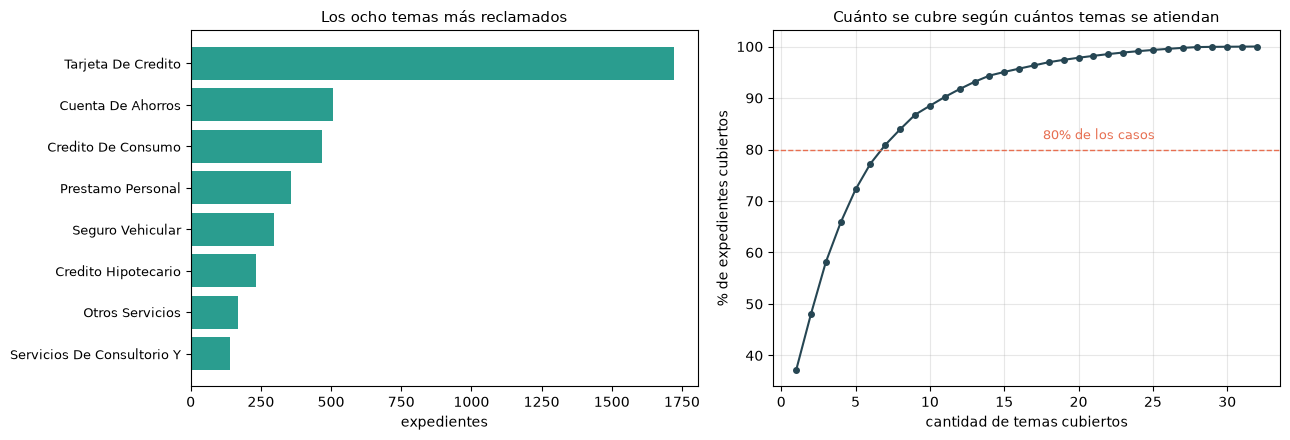

Con 7 de los 32 temas se cubre el 80% de los expedientes.


In [8]:
import matplotlib.pyplot as plt

fig, (izq, der) = plt.subplots(1, 2, figsize=(13, 4.5))

top = por_tema.head(8).sort_values()
izq.barh(range(len(top)), top.values, color="#2a9d8f")
izq.set_yticks(range(len(top)))
izq.set_yticklabels([t.title()[:26] for t in top.index], fontsize=9)
izq.set_xlabel("expedientes")
izq.set_title("Los ocho temas más reclamados", fontsize=11)

acum = (por_tema.cumsum() / por_tema.sum() * 100).values
der.plot(range(1, len(acum) + 1), acum, marker="o", color="#264653", markersize=4)
der.axhline(80, color="#e76f51", linestyle="--", linewidth=1)
der.text(len(acum) * 0.55, 82, "80% de los casos", color="#e76f51", fontsize=9)
der.set_xlabel("cantidad de temas cubiertos")
der.set_ylabel("% de expedientes cubiertos")
der.set_title("Cuánto se cubre según cuántos temas se atiendan", fontsize=11)
der.grid(alpha=0.3)

plt.tight_layout()
plt.show()

cuantos = int((acum <= 80).sum()) + 1
print(f"Con {cuantos} de los {len(por_tema)} temas se cubre el 80% de los expedientes.")

## 6. ¿Es estable o fue casualidad de un año?

Un hallazgo sobre un solo año puede ser una casualidad. Tenemos dos, así que se puede comprobar.

Esta es una costumbre que vale para todo el curso: antes de construir algo sobre un dato, mira si
ese dato se repite.

In [9]:
comparacion = pd.crosstab(datos["subsector"], datos["anio"])
comparacion["total"] = comparacion.sum(axis=1)
comparacion = comparacion.sort_values("total", ascending=False).head(8)

print("MISMO TEMA, LOS DOS AÑOS\n")
print(comparacion.drop(columns="total").to_string())

print("\n\nParticipación del tema principal en cada año:\n")
for anio in sorted(datos["anio"].unique()):
    del_anio = datos[datos["anio"] == anio]["subsector"].value_counts()
    principal = del_anio.index[0]
    print(f"  {int(anio)}: {principal} representa el "
          f"{del_anio.iloc[0]/del_anio.sum()*100:.0f}% de los expedientes")

MISMO TEMA, LOS DOS AÑOS

anio                                   2015  2016
subsector                                        
TARJETA DE CREDITO                      851   869
CUENTA DE AHORROS                       203   304
CREDITO DE CONSUMO                      331   136
PRESTAMO PERSONAL                       117   240
SEGURO VEHICULAR                        149   148
CREDITO HIPOTECARIO                     100   132
OTROS SERVICIOS                          52   117
SERVICIOS DE CONSULTORIO Y EMERGENCIA    79    61


Participación del tema principal en cada año:

  2015: TARJETA DE CREDITO representa el 37% de los expedientes
  2016: TARJETA DE CREDITO representa el 37% de los expedientes


El tema principal es el mismo los dos años y con prácticamente la misma participación. No es
casualidad de un año.

Eso da confianza para construir encima. Si el año siguiente el primer lugar fuera otro tema
distinto, la conclusión sería que este universo cambia rápido y que cualquier corpus quedaría
obsoleto pronto, lo que también sería una conclusión útil, pero llevaría a otra decisión.

In [10]:
# Algunos temas sí se movieron. Ver cuáles es tan interesante como ver los estables.
movimiento = pd.crosstab(datos["subsector"], datos["anio"])
movimiento.columns = [int(c) for c in movimiento.columns]
movimiento["cambio"] = movimiento[2016] - movimiento[2015]
notables = movimiento[movimiento[[2015, 2016]].max(axis=1) >= 100]

print("TEMAS CON MÁS DE 100 CASOS: cómo se movieron\n")
print(f"{'tema':<30} {'2015':>7} {'2016':>7} {'cambio':>9}")
print("-" * 56)
for tema, fila in notables.sort_values("cambio").iterrows():
    signo = "+" if fila["cambio"] > 0 else ""
    print(f"{tema[:28]:<30} {fila[2015]:>7} {fila[2016]:>7} {signo}{fila['cambio']:>8}")

TEMAS CON MÁS DE 100 CASOS: cómo se movieron

tema                              2015    2016    cambio
--------------------------------------------------------
CREDITO DE CONSUMO                 331     136     -195
SEGURO VEHICULAR                   149     148       -1
TARJETA DE CREDITO                 851     869 +      18
CREDITO HIPOTECARIO                100     132 +      32
OTROS SERVICIOS                     52     117 +      65
CUENTA DE AHORROS                  203     304 +     101
PRESTAMO PERSONAL                  117     240 +     123


Los movimientos también dicen cosas. Un tema que cae a la mitad y otro que se duplica en un año
suelen indicar un cambio de regulación, de producto o de la forma de clasificar los expedientes,
no un cambio real en la satisfacción de la gente.

Cuando veas un salto así en datos de tu propia organización, la primera hipótesis nunca debe ser
"mejoramos", sino "cambió cómo medimos".

## 7. Quién recibe los reclamos

La última mirada descriptiva: las empresas.

In [11]:
top_empresas = datos["denunciado"].value_counts().head(8)

print("EMPRESAS CON MÁS EXPEDIENTES\n")
for empresa, n in top_empresas.items():
    print(f"  {empresa[:52]:<54} {n:>5}")

print(f"\nHay {datos['denunciado'].nunique()} entidades distintas en total.")
concentracion = top_empresas.sum() / len(datos) * 100
print(f"Las ocho primeras concentran el {concentracion:.0f}% de los expedientes.")

EMPRESAS CON MÁS EXPEDIENTES

  BBVA BANCO CONTINENTAL S.A.                              422
  BANCO DE CRÉDITO DEL PERÚ S.A.                           352
  SCOTIABANK PERÚ S.A.A.                                   278
  BANCO FALABELLA PERÚ S.A.                                179
  BANCO DE CREDITO DEL PERU                                119
  BANCO INTERNACIONAL DEL PERÚ S.A.A. - INTERBANK          117
  SCOTIABANK PERU S.A.A.                                   112
  BANCO RIPLEY PERÚ S.A.                                   104

Hay 967 entidades distintas en total.
Las ocho primeras concentran el 36% de los expedientes.


Aquí hace falta una advertencia que es de método, no de datos, y que conviene decir en voz alta
antes de que alguien saque la conclusión equivocada.

**Estas cifras no miden la calidad del servicio de cada empresa.** Un banco con muchos clientes
va a acumular más expedientes que uno pequeño aunque atienda mejor. Para comparar habría que
dividir entre el número de clientes o de operaciones, y ese dato no está aquí.

Lo que sí se puede decir es dónde está el volumen, que para dimensionar un piloto es justamente lo
que hace falta.

Si alguien quisiera usar esta tabla para decir qué banco atiende peor, estaría cometiendo un error
elemental de análisis. Vale la pena reconocerlo, porque este tipo de conclusión aparece en la
prensa con frecuencia.

## 8. El puente: qué de esto atendería un chatbot

Todo lo anterior describe el problema. La pregunta del curso es qué parte de ese problema puede
atender un asistente automático.

La respuesta honesta es que **estos datos no lo dicen directamente**, porque no contienen el texto
de lo que preguntó cada persona. Lo que sí permiten es acotar el territorio y estimar el tamaño
del premio.

El razonamiento va así, y conviene que puedas defenderlo con números:

In [12]:
# Del universo total, ¿cuánto pesa el tema principal?
tema_principal = por_tema.index[0]
casos_principal = por_tema.iloc[0]

print(f"Tema principal: {tema_principal}")
print(f"   {casos_principal:,} expedientes en dos años "
      f"({casos_principal/len(datos)*100:.0f}% del total)")
print(f"   es decir, unos {casos_principal/24:.0f} al mes llegando al regulador\n")

# Un supuesto explícito, para poder discutirlo
print("Ahora un supuesto, que hay que decir en voz alta porque no sale de los datos:")
print("de cada persona que llega hasta el regulador, muchas más tuvieron el mismo")
print("problema y se quedaron en el canal de atención de la empresa.\n")

for multiplicador in (10, 50, 100):
    consultas = casos_principal / 24 * multiplicador
    print(f"   si por cada expediente hubo {multiplicador:>3} consultas previas -> "
          f"{consultas:>8,.0f} consultas al mes sobre este tema")

Tema principal: TARJETA DE CREDITO
   1,720 expedientes en dos años (37% del total)
   es decir, unos 72 al mes llegando al regulador

Ahora un supuesto, que hay que decir en voz alta porque no sale de los datos:
de cada persona que llega hasta el regulador, muchas más tuvieron el mismo
problema y se quedaron en el canal de atención de la empresa.

   si por cada expediente hubo  10 consultas previas ->      717 consultas al mes sobre este tema
   si por cada expediente hubo  50 consultas previas ->    3,583 consultas al mes sobre este tema
   si por cada expediente hubo 100 consultas previas ->    7,167 consultas al mes sobre este tema


Ese multiplicador no está en los datos y por eso se declara como supuesto, no como hallazgo. Es
la diferencia entre un análisis defendible y uno que se cae en la primera pregunta.

Lo que sí queda establecido, y es suficiente para decidir por dónde empezar:

**El territorio está acotado.** Cinco temas cubren tres cuartas partes de los casos. Un corpus de
preguntas frecuentes sobre esos cinco temas es un proyecto de semanas, no de años.

**El tema principal está identificado y es estable.** Las tarjetas de crédito, los dos años.

**El sector está identificado.** Servicios financieros, con diferencia.

Con eso ya se puede escribir la primera frase de una propuesta: "un asistente que responda
consultas sobre tarjetas de crédito, que es el tema que concentra el 37% de los expedientes de
protección al consumidor en el sector financiero".

Eso es muy distinto de "un chatbot para atención al cliente", que es lo que suele proponerse sin
datos.

## 9. Lo que estos datos no dicen

Esta sección es tan importante como los hallazgos, y es la que separa un análisis profesional de
una presentación bonita.

**No son interacciones de servicio.** Son expedientes ante el regulador: el final del camino, no
la conversación. La persona que llegó aquí ya pasó por el canal de atención de la empresa y no
quedó conforme. Lo que preguntó originalmente, y cómo se lo respondieron, no está en estos datos.

**No hay tiempos ni satisfacción.** No se puede calcular el tiempo medio de atención, ni la
resolución al primer contacto, ni ninguna de las métricas de calidad de servicio que viste en la
sesión anterior. Esos indicadores viven en los sistemas de cada empresa, no en un registro
público.

**Son de 2015 y 2016.** Es lo que está publicado. Sirve para entender la estructura del problema,
que cambia despacio, pero no para afirmar nada sobre la situación de hoy. Si esto fuera un
proyecto real, el primer pedido a la organización sería su propio registro de consultas
reciente.

**Solo cubren tres sectores.** Financiero, seguros y salud. No dice nada sobre retail,
telecomunicaciones o educación, que son sectores que probablemente elijan varios equipos.

**Miden lo denunciado, no lo ocurrido.** Un sector con clientes más informados o con más costumbre
de reclamar va a aparecer más, aunque su servicio no sea peor.

Ninguna de estas limitaciones invalida el análisis. Lo que hacen es delimitar qué afirmaciones se
sostienen. Un análisis que no las declara no es más fuerte: es más frágil, porque la primera
persona que las note va a dudar de todo lo demás.

## 10. Lo que te llevas

**Los problemas de servicio se concentran.** Cinco temas de treinta y dos cubren tres cuartas
partes de los expedientes. Esa forma se repite en casi cualquier operación, y es la razón por la que un
asistente acotado puede ser útil desde el primer día.

**Un hallazgo se comprueba en el tiempo.** El tema principal es el mismo los dos años y con la
misma participación. Si hubiera cambiado, la decisión sería otra.

**Los volúmenes no son calidad.** La empresa con más expedientes no es necesariamente la que peor
atiende: es, probablemente, la que más clientes tiene. Comparar sin normalizar es el error más
común con este tipo de datos.

**Los supuestos se declaran.** El salto de expedientes a consultas potenciales necesita un
multiplicador que no está en los datos. Decirlo no debilita la propuesta; la hace discutible, que
es lo que uno quiere en una reunión.

**Todo dato abierto tiene tres preguntas obligatorias**: quién lo publica, con qué licencia, y qué
contiene exactamente. Las tres se responden antes de abrir el archivo.

Y la que enmarca todo lo demás: los datos sirvieron para acotar el problema, no para resolverlo.
Ahora sabes sobre qué tema construir el corpus. Lo que ese corpus debe contener, cómo se recupera
y cómo se evalúa es el resto de la semana.